# 05 — Evaluation & Error Analysis

Task-appropriate metrics for this regression problem (RMSE, MAE, R²), plus a look at *where* and *why* each model's predictions go wrong — this is the part a metrics table alone can't tell you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
test_df = pd.read_csv('../data/processed/test_predictions.csv')
results = pd.read_csv('../models/test_set_results.csv', index_col='model')
results

,RMSE,MAE,R2
model,,,
Ridge,3.918672,2.965946,0.827393
RandomForest,1.840877,1.145665,0.961908
GradientBoosting,1.872710,1.262624,0.960580


## Metric comparison
**RMSE** and **MAE** are in years of life expectancy — directly interpretable. **R²** is the proportion of variance explained. We report all three because RMSE penalizes large errors more heavily than MAE, and comparing the two tells us whether a model's errors are dominated by a few big misses or spread evenly (RMSE noticeably larger than MAE → a few large misses).

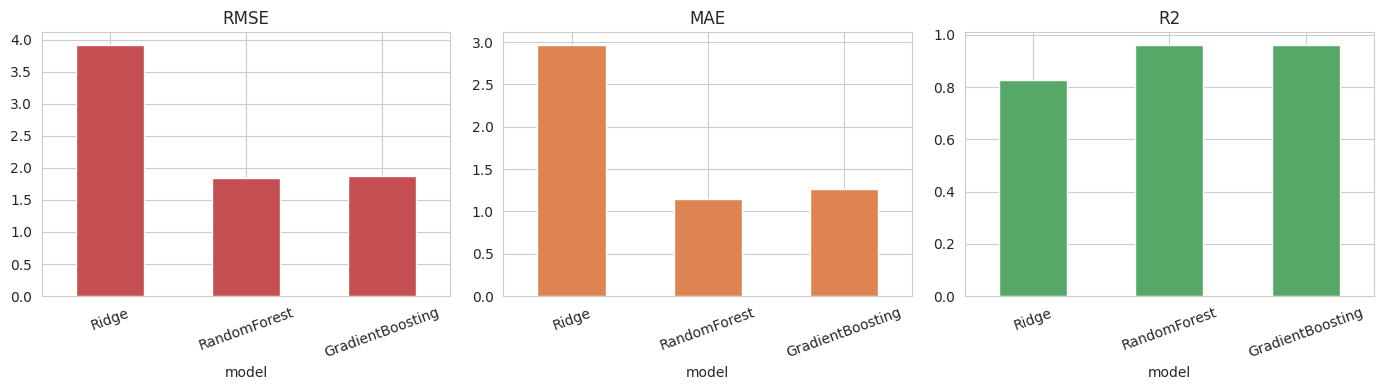

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, color in zip(axes, ['RMSE', 'MAE', 'R2'], ['#C44E52', '#DD8452', '#55A868']):
    results[metric].plot(kind='bar', ax=ax, color=color)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../figures/10_metric_comparison.png', dpi=120)
plt.show()

**Observation:** RMSE is meaningfully higher than MAE for every model (e.g. Random Forest: RMSE 1.84 vs MAE 1.15), confirming errors aren't uniform — a subset of predictions miss by a lot more than the typical case. We investigate exactly which ones below. Ridge's much larger gap to the tree models (R² 0.83 vs ~0.96) confirms the non-linear relationships flagged back in notebook 03/04 (diminishing returns of GDP, schooling, etc.) are real and matter for this target.

## Actual vs. predicted

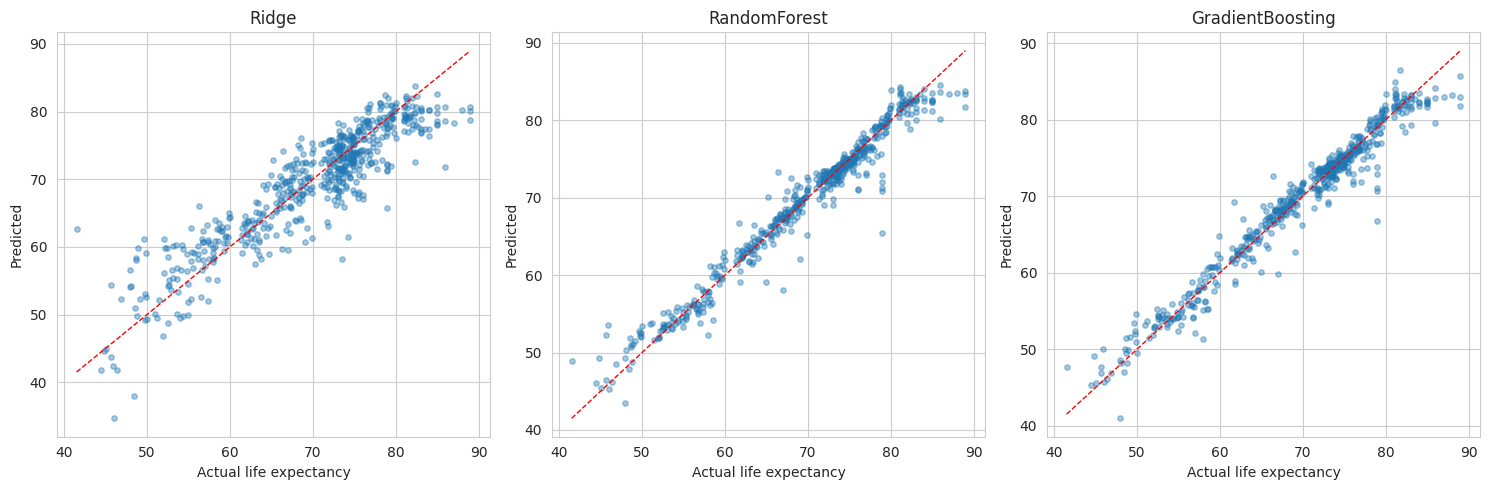

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, model in zip(axes, ['Ridge', 'RandomForest', 'GradientBoosting']):
    ax.scatter(test_df['y_true'], test_df[f'pred_{model}'], alpha=0.4, s=15)
    lims = [test_df['y_true'].min(), test_df['y_true'].max()]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual life expectancy')
    ax.set_ylabel('Predicted')
    ax.set_title(model)
plt.tight_layout()
plt.savefig('../figures/11_actual_vs_predicted.png', dpi=120)
plt.show()

**Observation:** Ridge visibly bows away from the diagonal at the low end (below ~55 years) — it systematically **overpredicts** life expectancy for the worst-off countries, i.e. it can't fully capture how bad things get in crisis-level cases. Both tree ensembles hug the diagonal much more tightly across the whole range, including that low tail.

## Residual analysis

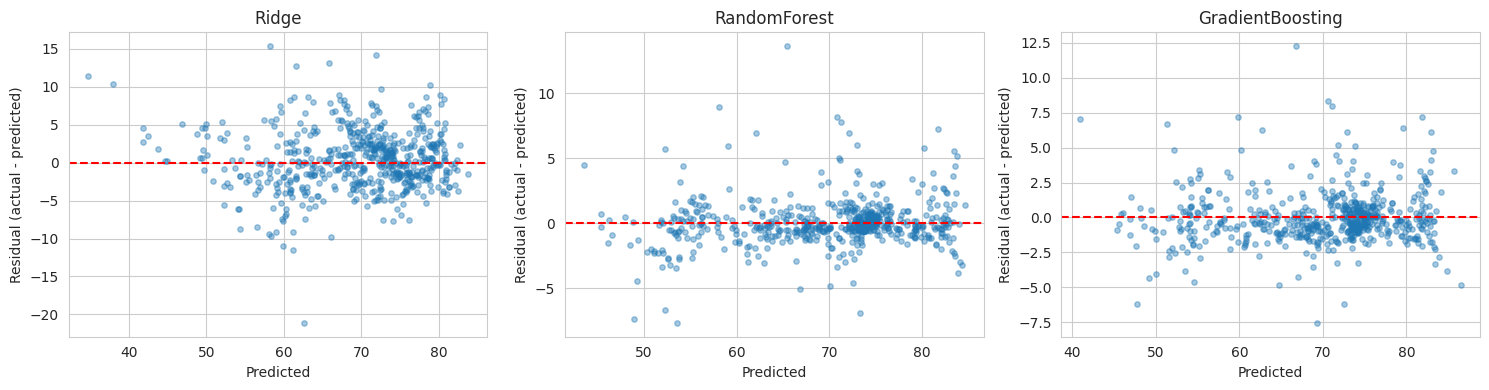

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model in zip(axes, ['Ridge', 'RandomForest', 'GradientBoosting']):
    residuals = test_df['y_true'] - test_df[f'pred_{model}']
    ax.scatter(test_df[f'pred_{model}'], residuals, alpha=0.4, s=15)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (actual - predicted)')
    ax.set_title(model)
plt.tight_layout()
plt.savefig('../figures/12_residuals.png', dpi=120)
plt.show()

**Observation:** Ridge's residuals show a clear funnel/curve pattern (not random scatter around zero) — a classic sign the model is misspecified (missing non-linear terms), consistent with the actual-vs-predicted plot above. Random Forest and Gradient Boosting residuals scatter much closer to a random band around zero, though both still show a bit more spread at the low-life-expectancy end where data is sparser.

## Where does the best model (Random Forest) fail hardest?
Looking at the 15 largest absolute errors, by country, to see if there's a pattern.

In [5]:
test_df['abs_error_rf'] = (test_df['y_true'] - test_df['pred_RandomForest']).abs()
worst = test_df.sort_values('abs_error_rf', ascending=False).head(15)
worst[['country', 'year', 'y_true', 'pred_RandomForest', 'abs_error_rf', 'status_developed', 'hiv_aids', 'adult_mortality']]

,country,year,y_true,pred_RandomForest,abs_error_rf,status_developed,hiv_aids,adult_mortality
446,Saint Vincent and the Grenadines,2000,79.0,65.398904,13.601096,0,0.7,186.0
475,Zimbabwe,2015,67.0,58.103145,8.896855,0,6.2,336.0
10,Saint Vincent and the Grenadines,2001,79.0,70.876881,8.123119,0,0.7,186.0
222,Saint Vincent and the Grenadines,2002,79.0,71.256547,7.743453,0,0.4,186.0
145,Swaziland,2003,45.9,53.570992,7.670992,0,50.6,6.0
392,Sierra Leone,2003,41.5,48.864635,7.364635,0,1.9,57.0
382,Spain,2007,89.0,81.760485,7.239515,1,0.1,72.0
108,Madagascar,2005,69.0,62.047669,6.952331,0,0.6,265.0
385,Russian Federation,2006,66.4,73.341913,6.941913,0,0.3,3.0
558,Guatemala,2008,79.0,72.078040,6.921960,0,0.4,19.0


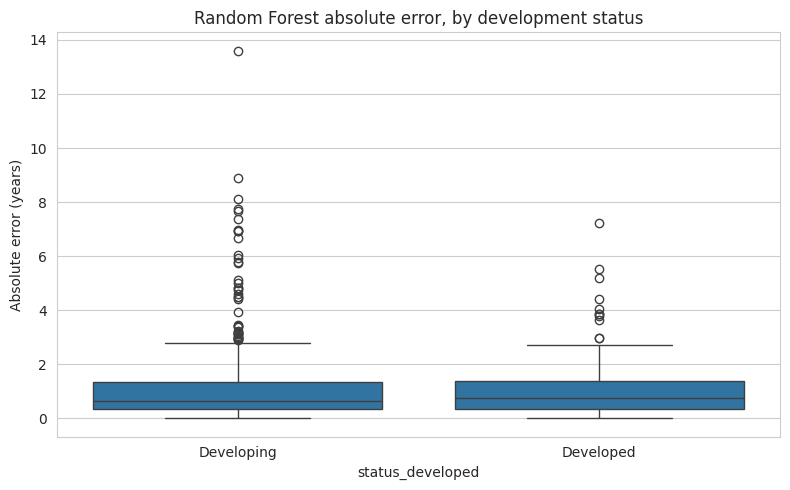

                      mean    median       std
status_developed                              
0                 1.138838  0.649495  1.466046
1                 1.178445  0.747160  1.327826


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=test_df['status_developed'].map({0: 'Developing', 1: 'Developed'}),
            y=test_df['abs_error_rf'], ax=ax)
ax.set_title('Random Forest absolute error, by development status')
ax.set_ylabel('Absolute error (years)')
plt.tight_layout()
plt.savefig('../figures/13_error_by_status.png', dpi=120)
plt.show()

print(test_df.groupby('status_developed')['abs_error_rf'].agg(['mean', 'median', 'std']))

**Observation:** the mean absolute error is actually about the same for Developing (1.14 years) and Developed (1.18 years) countries — **development status alone is not what drives the biggest errors**, which rules out our initial hypothesis. Looking at the 15 worst individual cases instead reveals two distinct patterns:

1. **Extreme-HIV/AIDS-prevalence countries at the low end of life expectancy are underestimated in severity.** Swaziland (~50% HIV/AIDS prevalence, actual life expectancy 45.6–45.9) and Sierra Leone (2003, actual 41.5) are all predicted 6–8 years *higher* than reality — the model knows high HIV prevalence lowers life expectancy, but underestimates just how severe the effect is at the extreme end, likely because so few country-years in the training data sit at that extreme.
2. **Small nations with suspiciously flat repeated values are actually a data-quality artifact, not a modeling failure.** Saint Vincent and the Grenadines reports *exactly* 79.0 for three consecutive years (2000–2002) — a strong sign the original source carried forward a stale/estimated figure rather than a fresh measurement each year. The model (correctly) predicts a value informed by that country's actual indicators, which don't perfectly match a number that wasn't really re-measured. This is a limitation of the *data*, not the *model*.

## Summary: where and why the model fails
1. **Linear model (Ridge) fails structurally** — the true relationship between predictors like GDP, schooling, and HIV/AIDS prevalence and life expectancy is non-linear (diminishing/accelerating returns), which no amount of regularization fixes. This is a *model choice* problem, not a data problem.
2. **Tree ensembles fail at the edges, not the middle** — both Random Forest and Gradient Boosting are highly accurate (R² > 0.96) in the typical range but lose accuracy at the extreme low end of life expectancy (severe HIV/AIDS epidemics, conflict-driven crises), which are rare in the training data and don't fit the pattern learned from the majority of 'normal' country-years.
3. **Development status by itself is not a good predictor of error size** — mean absolute error is nearly identical between Developing and Developed countries (1.14 vs 1.18 years). What actually predicts large errors is being an *extreme outlier on a specific indicator* (very high HIV prevalence), not a country's broad development category.
4. **Some 'errors' are really data-quality artifacts inherited from the source**, not model failures — e.g. a country reporting the exact same life-expectancy figure for several consecutive years, which the model has no way to know is a stale/carried-forward value rather than a fresh measurement.
5. **Practical implication:** Random Forest is the best model for this task (lowest RMSE/MAE, highest R²), but predictions near the extreme low end of the life-expectancy range should be treated with more caution than the aggregate R² of 0.96 suggests.